# Importing the dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rarfile

In [ ]:
import rarfile
import os

In [ ]:
rar_ref = rarfile.RarFile("drive/MyDrive/imgs.rar")

rar_ref.extractall()
rar_ref.close()

# Importing the libraries

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import MaxPooling2D, Dense, Flatten, Conv2D,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import json
import albumentations as A
import pandas as pd
from tensorflow.keras.utils import to_categorical,Sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import cv2

# Preprocessing

In [ ]:
# Paths to dataset
json_dir = "imgs"
image_dir = "imgs"
train_csv = "train_eye_gaze.csv"
test_csv = "test_eye_gaze.csv"

data = []

for file_name in os.listdir(json_dir):
    if file_name.endswith(".json"):
        json_path = os.path.join(json_dir, file_name)

        with open(json_path, 'r') as f:
            json_data = json.load(f)

        # Extract gaze direction (look_vec)
        look_vec = json_data["eye_details"]["look_vec"]
        look_vec = list(map(float, look_vec.strip("()").split(",")))[:2]  # Only take x, y

        # Extract eye region landmarks
        eye_landmarks = json_data["interior_margin_2d"]
        eye_points = [tuple(list(map(float, p.strip("()").split(",")))[:2]) for p in eye_landmarks]

        # Compute bounding box of eye region
        x_min = int(min(p[0] for p in eye_points))
        x_max = int(max(p[0] for p in eye_points))
        y_min = int(min(p[1] for p in eye_points))
        y_max = int(max(p[1] for p in eye_points))

        # Store data (image path, gaze_x, gaze_y, bounding box)
        image_name = file_name.replace(".json", ".jpg")  # Assuming images are .png
        data.append([image_name, look_vec[0], look_vec[1], x_min, y_min, x_max, y_max])

# Save as CSV
df = pd.DataFrame(data, columns=["image", "gaze_x", "gaze_y", "x_min", "y_min", "x_max", "y_max"])
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42);

X_train.to_csv(train_csv, index=False)
X_test.to_csv(test_csv, index=False)

print(f"Dataset successfully created with {len(df)} samples.")

Dataset successfully created with 5024 samples.


In [ ]:
class UnityEyesDataset(Sequence):
    def __init__(self, image_dir, csv_path, batch_size=32, img_size=(64, 64), shuffle=True):
        self.image_dir = image_dir
        self.data = pd.read_csv(csv_path)
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.data))

        self.augment = A.Compose([
            A.Resize(self.img_size[0], self.img_size[1]),
            A.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return int(np.floor(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = self.data.iloc[batch_indexes]

        images, labels = [], []
        for _, row in batch_data.iterrows():
            img_path = os.path.join(self.image_dir, row["image"])
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Crop the eye region
            x_min, y_min, x_max, y_max = row["x_min"], row["y_min"], row["x_max"], row["y_max"]
            eye_crop = img[y_min:y_max, x_min:x_max]

            # Resize and normalize
            eye_crop = self.augment(image=eye_crop)["image"]

            images.append(eye_crop)
            labels.append([row["gaze_x"], row["gaze_y"]])

        return np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


In [ ]:
train_generator = UnityEyesDataset("imgs", "train_eye_gaze.csv", batch_size=32)
test_generator = UnityEyesDataset("imgs", "test_eye_gaze.csv", batch_size=32)

In [ ]:
len(train_generator)

125

# Creating the Model Architecture

In [ ]:
def create_model():
    model = Sequential([
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        MaxPooling2D(2,2),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2)  # Output: Gaze X and Y
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Instantiate model
model = create_model()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# Train the model

model_hist = model.fit(train_generator,epochs=5,steps_per_epoch=len(train_generator), validation_data=test_generator, validation_steps=len(test_generator))

# Save model
model.save("gaze_estimation_model.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - loss: 0.1148 - mae: 0.2599 - val_loss: 0.0496 - val_mae: 0.1624
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - loss: 0.0551 - mae: 0.1725 - val_loss: 0.0389 - val_mae: 0.1378
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 270ms/step - loss: 0.0483 - mae: 0.1583 - val_loss: 0.0364 - val_mae: 0.1306
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - loss: 0.0418 - mae: 0.1463 - val_loss: 0.0340 - val_mae: 0.1257
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - loss: 0.0424 - mae: 0.1456 - val_loss: 0.0335 - val_mae: 0.1269


In [ ]:
model_hist.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

# Model accuracy validation

In [ ]:
def plot_loss_curve(history):

  """
  plots the training accuracy, training loss and validation accuracy and validation loss

  example use of the function
  plot_loss_curve(model_history)

  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  accuracy = history.history['mae']
  val_accuracy = history.history['val_mae']
  epochs = range(len(history.history['val_mae']))

  plt.plot(epochs,loss,label="training_loss")
  plt.plot(epochs,val_loss,label="val_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  plt.figure()
  plt.plot(epochs,accuracy,label="training_accuracy")
  plt.plot(epochs,val_accuracy,label="val_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

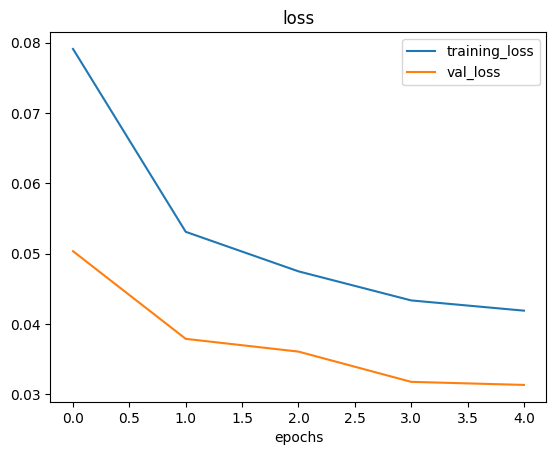

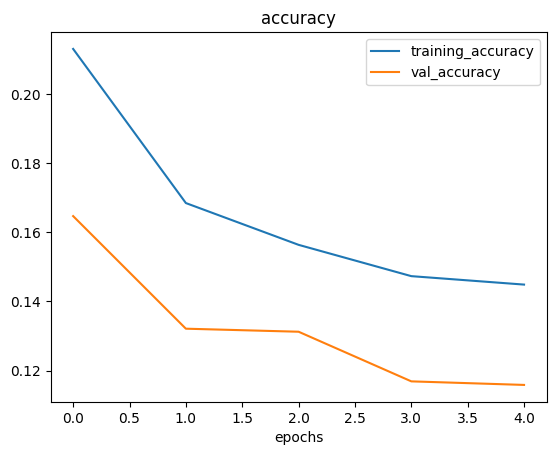

In [ ]:
plot_loss_curve(model_hist)

In [ ]:
model.evaluate(test_generator)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0314 - mae: 0.1166


[0.03137431666254997, 0.11582551151514053]